In [1]:
import pyopenms.Constants

help(pyopenms.Constants)

C:\Users\jiawe\.conda\envs\bio\Lib\site-packages\pyopenms\__init__.py:41: UserWarning: Warning: OPENMS_DATA_PATH environment variable already exists. pyOpenMS will use it (C:\Program Files\OpenMS-3.4.1\share\OpenMS) to locate data in the OpenMS share folder (e.g., the unimod database), instead of the default (C:\Users\jiawe\.conda\envs\bio\Lib\site-packages\pyopenms\share/OpenMS).
  warnings.warn(


Help on module pyopenms.Constants in pyopenms:

NAME
    pyopenms.Constants

DESCRIPTION
    # @brief Mathematical and physical constants namespace.
    # 
    # This namespace contains definitions for some basic mathematical and physical constants.
    # All constants are double precision.

DATA
    AVOGADRO = 6.0221367e+23
    BOHR_RADIUS = 5.29177249e-11
    BOLTZMANN = 1.380657e-23
    C13C12_MASSDIFF_U = 1.0033548378
    CAL_PER_JOULE = 0.2390057361376673
    DEG_PER_RAD = 57.29577951308232
    E = 2.718281828459045
    ELECTRON_MASS = 9.1093897e-31
    ELECTRON_MASS_U = 0.0005485799042984105
    ELEMENTARY_CHARGE = 1.60217738e-19
    EPSILON = 1e-06
    F = 96485.31200007845
    FARADAY = 96485.31200007845
    FINE_STRUCTURE_CONSTANT = 0.00729735
    FRAGMENT_ANNOTATION_USERPARAM = 'fragment_annotation'
    GAS_CONSTANT = 8.314505189811898
    GRAVITATIONAL_CONSTANT = 6.67259e-11
    JOULE_PER_CAL = 4.184
    MM_PER_INCH = 25.4
    MOL = 6.0221367e+23
    M_PER_FOOT = 3.048
    N

In [2]:
import pyopenms as oms

edb = oms.ElementDB()

edb.hasElement("O")
edb.hasElement("S")

oxygen = edb.getElement("O")
print(oxygen.getName())
print(oxygen.getSymbol())
print(oxygen.getMonoWeight())
print(oxygen.getAverageWeight())

sulfur = edb.getElement("S")
print(sulfur.getName())
print(sulfur.getSymbol())
print(sulfur.getMonoWeight())
print(sulfur.getAverageWeight())
isotopes = sulfur.getIsotopeDistribution()

print("One mole of oxygen weighs", 2 * oxygen.getAverageWeight(), "grams")
print("One mole of 16O2 weighs", 2 * oxygen.getMonoWeight(), "grams")

Oxygen
O
15.994915
15.999405323160001
Sulfur
S
31.97207073
32.066084735289
One mole of oxygen weighs 31.998810646320003 grams
One mole of 16O2 weighs 31.98983 grams


In [3]:
edb = oms.ElementDB()
oxygen_isoDist = {"mass": [], "abundance": []}
sulfur_isoDist = {"mass": [], "abundance": []}

oxygen = edb.getElement("O")
isotopes = oxygen.getIsotopeDistribution()
for iso in isotopes.getContainer():
    print(
        "Oxygen isotope",
        iso.getMZ(),
        "has abundance",
        iso.getIntensity() * 100,
        "%",
    )
    oxygen_isoDist["mass"].append(iso.getMZ())
    oxygen_isoDist["abundance"].append((iso.getIntensity() * 100))

sulfur = edb.getElement("S")
isotopes = sulfur.getIsotopeDistribution()
for iso in isotopes.getContainer():
    print(
        "Sulfur isotope",
        iso.getMZ(),
        "has abundance",
        iso.getIntensity() * 100,
        "%",
    )
    sulfur_isoDist["mass"].append(iso.getMZ())
    sulfur_isoDist["abundance"].append((iso.getIntensity() * 100))

Oxygen isotope 15.994915 has abundance 99.75699782371521 %
Oxygen isotope 16.999132 has abundance 0.03800000122282654 %
Oxygen isotope 17.999169 has abundance 0.20500000100582838 %
Sulfur isotope 31.97207073 has abundance 94.92999911308289 %
Sulfur isotope 32.971458 has abundance 0.7600000128149986 %
Sulfur isotope 33.967867 has abundance 4.2899999767541885 %
Sulfur isotope 35.967081 has abundance 0.019999999494757503 %


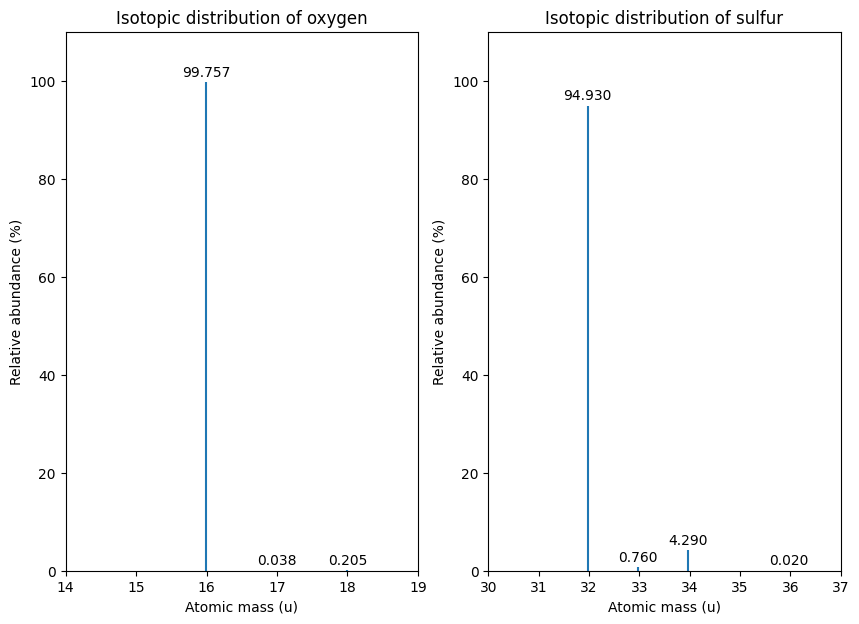

In [4]:
import math
from matplotlib import pyplot as plt


# very simple overlapping correction of annotations
def adjustText(x1, y1, x2, y2):
    if y1 > y2:
        plt.annotate(
            "%0.3f" % (y2),
            xy=(x2, y2),
            xytext=(x2 + 0.5, y2 + 9),
            textcoords="data",
            arrowprops=dict(arrowstyle="->", color="r", lw=0.5),
            horizontalalignment="right",
            verticalalignment="top",
        )
    else:
        plt.annotate(
            "%0.3f" % (y1),
            xy=(x1, y1),
            xytext=(x1 + 0.5, y1 + 9),
            textcoords="data",
            arrowprops=dict(arrowstyle="->", color="r", lw=0.5),
            horizontalalignment="right",
            verticalalignment="top",
        )


def plotDistribution(distribution):
    n = len(distribution["mass"])
    for i in range(0, n):
        plt.vlines(
            x=distribution["mass"][i], ymin=0, ymax=distribution["abundance"][i]
        )
        if (
            int(distribution["mass"][i - 1]) == int(distribution["mass"][i])
            and i != 0
        ):
            adjustText(
                distribution["mass"][i - 1],
                distribution["abundance"][i - 1],
                distribution["mass"][i],
                distribution["abundance"][i],
            )
        else:
            plt.text(
                x=distribution["mass"][i],
                y=(distribution["abundance"][i] + 2),
                s="%0.3f" % (distribution["abundance"][i]),
                va="center",
                ha="center",
            )
    plt.ylim([0, 110])
    plt.xticks(
        range(
            math.ceil(distribution["mass"][0]) - 2,
            math.ceil(distribution["mass"][-1]) + 2,
        )
    )


plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
plt.title("Isotopic distribution of oxygen")
plotDistribution(oxygen_isoDist)
plt.xlabel("Atomic mass (u)")
plt.ylabel("Relative abundance (%)")

plt.subplot(1, 2, 2)
plt.title("Isotopic distribution of sulfur")
plotDistribution(sulfur_isoDist)
plt.xlabel("Atomic mass (u)")
plt.ylabel("Relative abundance (%)")

plt.show()

In [5]:
edb = oms.ElementDB()
isotopes = edb.getElement("C").getIsotopeDistribution().getContainer()
carbon_isotope_difference = isotopes[1].getMZ() - isotopes[0].getMZ()
isotopes = edb.getElement("N").getIsotopeDistribution().getContainer()
nitrogen_isotope_difference = isotopes[1].getMZ() - isotopes[0].getMZ()

print("Mass difference between 12C and 13C:", carbon_isotope_difference)
print("Mass difference between 14N and N15:", nitrogen_isotope_difference)
print(
    "Relative deviation:",
    100
    * (carbon_isotope_difference - nitrogen_isotope_difference)
    / carbon_isotope_difference,
    "%",
)

Mass difference between 12C and 13C: 1.0033550000000009
Mass difference between 14N and N15: 0.9970350000000003
Relative deviation: 0.6298867300208343 %


In [6]:
from pyopenms.Constants import PROTON_MASS_U, ELECTRON_MASS_U, NEUTRON_MASS_U

helium = oms.ElementDB().getElement("He")
isotopes = helium.getIsotopeDistribution()

mass_sum = 2 * PROTON_MASS_U + 2 * ELECTRON_MASS_U + 2 * NEUTRON_MASS_U
helium4 = isotopes.getContainer()[1].getMZ()
print("Sum of masses of 2 protons, neutrons and electrons:", mass_sum)
print("Mass of He4:", helium4)
print(
    "Difference between the two masses:",
    100 * (mass_sum - helium4) / mass_sum,
    "%",
)

Sum of masses of 2 protons, neutrons and electrons: 4.032979924670597
Mass of He4: 4.00260325415
Difference between the two masses: 0.7532065888743016 %


In [7]:
methanol = oms.EmpiricalFormula("CH3OH")
water = oms.EmpiricalFormula("H2O")
ethanol = oms.EmpiricalFormula("CH2") + methanol
print("Ethanol chemical formula:", ethanol.toString())
print("Ethanol composition:", ethanol.getElementalComposition())
print("Ethanol has", ethanol.getElementalComposition()[b"H"], "hydrogen atoms")

Ethanol chemical formula: C2H6O1
Ethanol composition: {b'C': 2, b'H': 6, b'O': 1}
Ethanol has 6 hydrogen atoms


In [8]:
ethanol = oms.EmpiricalFormula("C2H6O")
print("Ethanol chemical formula:", ethanol.toString())
print("Ethanol composition:", ethanol.getElementalComposition())
print("Ethanol weight:", ethanol.getMonoWeight())

ethanol = oms.EmpiricalFormula("(13)C1CH6O")
print("Ethanol chemical formula:", ethanol.toString())
print("Ethanol composition:", ethanol.getElementalComposition())
print("Ethanol weight:", ethanol.getMonoWeight())

ethanol = oms.EmpiricalFormula("(13)C2H6O")
print("Ethanol chemical formula:", ethanol.toString())
print("Ethanol composition:", ethanol.getElementalComposition())
print("Ethanol weight:", ethanol.getMonoWeight())

Ethanol chemical formula: C2H6O1
Ethanol composition: {b'C': 2, b'H': 6, b'O': 1}
Ethanol weight: 46.0418651914
Ethanol chemical formula: (13)C1C1H6O1
Ethanol composition: {b'(13)C': 1, b'C': 1, b'H': 6, b'O': 1}
Ethanol weight: 47.0452201914
Ethanol chemical formula: (13)C2H6O1
Ethanol composition: {b'(13)C': 2, b'H': 6, b'O': 1}
Ethanol weight: 48.0485751914


In [9]:
methanol = oms.EmpiricalFormula("CH3OH")
ethanol = oms.EmpiricalFormula("CH2") + methanol

methanol_isoDist = {"mass": [], "abundance": []}
ethanol_isoDist = {"mass": [], "abundance": []}

print("Coarse Isotope Distribution:")
isotopes = ethanol.getIsotopeDistribution(oms.CoarseIsotopePatternGenerator(4))
prob_sum = sum([iso.getIntensity() for iso in isotopes.getContainer()])
print("This covers", prob_sum, "probability")
for iso in isotopes.getContainer():
    print(
        "Isotope", iso.getMZ(), "has abundance", iso.getIntensity() * 100, "%"
    )
    methanol_isoDist["mass"].append(iso.getMZ())
    methanol_isoDist["abundance"].append((iso.getIntensity() * 100))

print("Fine Isotope Distribution:")
isotopes = ethanol.getIsotopeDistribution(oms.FineIsotopePatternGenerator(1e-3))
prob_sum = sum([iso.getIntensity() for iso in isotopes.getContainer()])
print("This covers", prob_sum, "probability")
for iso in isotopes.getContainer():
    print(
        "Isotope", iso.getMZ(), "has abundance", iso.getIntensity() * 100, "%"
    )
    ethanol_isoDist["mass"].append(iso.getMZ())
    ethanol_isoDist["abundance"].append((iso.getIntensity() * 100))

Coarse Isotope Distribution:
This covers 1.0000000131221896 probability
Isotope 46.0418651914 has abundance 97.56630063056946 %
Isotope 47.045220029199996 has abundance 2.214995212852955 %
Isotope 48.048574867 has abundance 0.21421683486551046 %
Isotope 49.0519297048 has abundance 0.004488633931032382 %
Fine Isotope Distribution:
This covers 0.9994461630121805 probability
Isotope 46.0418651914 has abundance 97.5662887096405 %
Isotope 47.0452201914 has abundance 2.110501006245613 %
Isotope 47.0481419395 has abundance 0.06732848123647273 %
Isotope 48.046119191399995 has abundance 0.20049810409545898 %


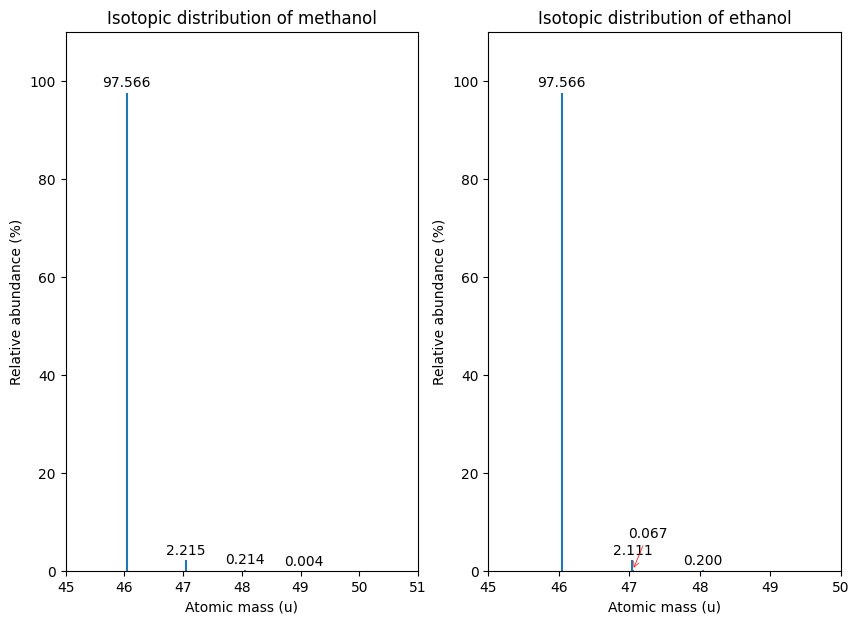

In [10]:
plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
plt.title("Isotopic distribution of methanol")
plotDistribution(methanol_isoDist)
plt.xlabel("Atomic mass (u)")
plt.ylabel("Relative abundance (%)")

plt.subplot(1, 2, 2)
plt.title("Isotopic distribution of ethanol")
plotDistribution(ethanol_isoDist)
plt.xlabel("Atomic mass (u)")
plt.ylabel("Relative abundance (%)")

plt.savefig("methanol_ethanol_isoDistribution.png")

In [11]:
methanol = oms.EmpiricalFormula("CH3OH")
ethanol = oms.EmpiricalFormula("CH2") + methanol

print("Fine Isotope Distribution:")
isotopes = ethanol.getIsotopeDistribution(oms.FineIsotopePatternGenerator(1e-6))
prob_sum = sum([iso.getIntensity() for iso in isotopes.getContainer()])
print("This covers", prob_sum, "probability")
for iso in isotopes.getContainer():
    print(
        "Isotope", iso.getMZ(), "has abundance", iso.getIntensity() * 100, "%"
    )

Fine Isotope Distribution:
This covers 0.9999993089130612 probability
Isotope 46.0418651914 has abundance 97.5662887096405 %
Isotope 47.0452201914 has abundance 2.110501006245613 %
Isotope 47.046082191400004 has abundance 0.03716550418175757 %
Isotope 47.0481419395 has abundance 0.06732848123647273 %
Isotope 48.046119191399995 has abundance 0.20049810409545898 %
Isotope 48.0485751914 has abundance 0.011413302854634821 %
Isotope 48.0494371914 has abundance 0.0008039440217544325 %
Isotope 48.0514969395 has abundance 0.0014564131561201066 %
Isotope 49.049474191399995 has abundance 0.004337066275184043 %
Isotope 49.0523959395 has abundance 0.00013835959862262825 %


In [12]:
isotopes = ethanol.getIsotopeDistribution(
    oms.CoarseIsotopePatternGenerator(5, True)
)
for iso in isotopes.getContainer():
    print(
        "Isotope", iso.getMZ(), "has abundance", iso.getIntensity() * 100, "%"
    )

Isotope 46.0 has abundance 97.56627082824707 %
Isotope 47.0 has abundance 2.21499465405941 %
Isotope 48.0 has abundance 0.21421676501631737 %
Isotope 49.0 has abundance 0.00448863283963874 %
Isotope 50.0 has abundance 2.6492455162951956e-05 %


In [13]:
lys = oms.ResidueDB().getResidue("Lysine")
print(lys.getName())
print(lys.getThreeLetterCode())
print(lys.getOneLetterCode())
print(lys.getAverageWeight())
print(lys.getMonoWeight())
print(lys.getPka())
print(lys.getFormula().toString())

Lysine
Lys
K
146.18788276708443
146.1055284466
2.16
C6H14N2O2


In [14]:
ox = oms.ModificationsDB().getModification("Oxidation")
print(ox.getUniModAccession())
print(ox.getUniModRecordId())
print(ox.getDiffMonoMass())
print(ox.getId())
print(ox.getFullId())
print(ox.getFullName())
print(ox.getDiffFormula())

UniMod:35
35
15.994915
Oxidation
Oxidation (V)
Oxidation or Hydroxylation
O1


In [15]:
isotopes = ox.getDiffFormula().getIsotopeDistribution(
    oms.CoarseIsotopePatternGenerator(5)
)
for iso in isotopes.getContainer():
    print(iso.getMZ(), ":", iso.getIntensity())

15.994915 : 0.9975699782371521
16.998269837800002 : 0.0003800000122282654
18.0016246756 : 0.002050000010058284


In [16]:
num_mod = oms.ModificationsDB().getNumberOfModifications()

all_mods = {}
for index in range(0, num_mod):
    mod = oms.ModificationsDB().getModification(index)
    all_mods[mod.getUniModRecordId()] = mod

In [17]:
# obtain modification with UniMod Accession 122
ox = all_mods[122]

print(ox.getUniModAccession())
print(ox.getUniModRecordId())
print(ox.getDiffMonoMass())
print(ox.getId())
print(ox.getFullId())
print(ox.getFullName())
print(ox.getDiffFormula())

UniMod:122
122
27.994915
Formyl
Formyl (S)
Formylation
C1O1


In [18]:
uridine = oms.RibonucleotideDB().getRibonucleotide(b"U")
print(uridine.getName())
print(uridine.getCode())
print(uridine.getAvgMass())
print(uridine.getMonoMass())
print(uridine.getFormula().toString())
print(uridine.isModified())
methyladenosine = oms.RibonucleotideDB().getRibonucleotide(b"m1A")
print(methyladenosine.getName())
print(methyladenosine.isModified())

uridine
U
244.201
244.0695
C9H12N2O6
False
1-methyladenosine
True


In [19]:
import pyopenms as oms

seq = oms.AASequence.fromString("DFPIANGER")
print("[M+H]+ weight:", seq.getMonoWeight(oms.Residue.ResidueType.Full, 1))

## get isotopic distribution for two additional hydrogens (which carry the charge)
charge = 2
seq_formula = seq.getFormula() + oms.EmpiricalFormula("H" + str(charge))
isotopes = seq_formula.getIsotopeDistribution(oms.CoarseIsotopePatternGenerator(6))

# Append isotopic distribution to spectrum
s = oms.MSSpectrum()
for iso in isotopes.getContainer():  # the container contains masses, not m/z!
    iso.setMZ(iso.getMZ() / charge) #  ... even though it's called '.getMZ()'
    s.push_back(iso)
    print("Isotope", iso.getMZ(), ":", iso.getIntensity())

# deisotope with 10 ppm mass tolerance
oms.Deisotoper.deisotopeAndSingleChargeDefault(s, 10, True)

for p in s:
    print("Mono peaks:", p.getMZ(), p.getIntensity())

[M+H]+ weight: 1018.495240604071
Isotope 509.75180710055 : 0.5680345296859741
Isotope 510.25348451945 : 0.3053518533706665
Isotope 510.75516193835 : 0.0980687290430069
Isotope 511.25683935725004 : 0.02330925688147545
Isotope 511.75851677615003 : 0.004496922250837088
Isotope 512.2601941950501 : 0.0007386932265944779
Mono peaks: 1018.496337734329 0.5680345296859741


In [20]:
seq = oms.AASequence.fromString("DFPIANGERDFPIANGERDFPIANGERDFPIANGER")
print("[M+H]+ weight:", seq.getMonoWeight(oms.Residue.ResidueType.Full, 1))

charge = 4
seq_formula = seq.getFormula() + oms.EmpiricalFormula("H" + str(charge))
isotopes = seq_formula.getIsotopeDistribution(oms.CoarseIsotopePatternGenerator(8))

# Append isotopic distribution to spectrum
s = oms.MSSpectrum()
for iso in isotopes.getContainer():
    iso.setMZ(iso.getMZ() / charge)
    s.push_back(iso)
    print("Isotope", iso.getMZ(), ":", iso.getIntensity())

min_charge = 1
min_isotopes = 2
max_isotopes = 10
use_decreasing_model = True   # ignores all intensities
start_intensity_check = 3     # here, the value does not matter, since we ignore intensities (see above)
oms.Deisotoper.deisotopeAndSingleCharge( ## a function with all parameters exposed
    s,
    10,
    True,
    min_charge,
    charge,
    True,
    min_isotopes,
    max_isotopes,
    True,
    True,
    True,
    use_decreasing_model,
    start_intensity_check,
    False,
    True
)
for p in s:
    print("Mono peaks:", p.getMZ(), p.getIntensity())

[M+H]+ weight: 4016.927437824572
Isotope 1004.9878653713499 : 0.10543462634086609
Isotope 1005.2387040808 : 0.22646740078926086
Isotope 1005.48954279025 : 0.25444599986076355
Isotope 1005.7403814996999 : 0.198257714509964
Isotope 1005.9912202091499 : 0.12000058591365814
Isotope 1006.2420589185999 : 0.05997776985168457
Isotope 1006.49289762805 : 0.025713209062814713
Isotope 1006.7437363375 : 0.009702673181891441
Mono peaks: 4016.9296320850867 0.10543462634086609


140
45
974.4572680576728 6200571.5
974.4589691256419 3215808.75


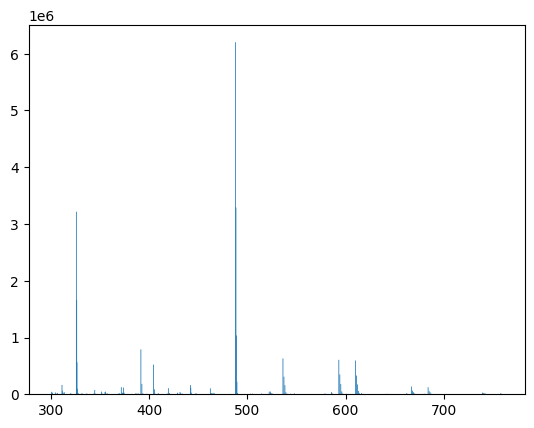

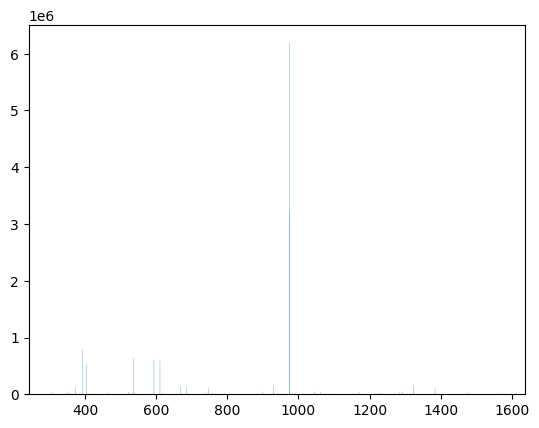

In [21]:
from urllib.request import urlretrieve
import matplotlib.pyplot as plt

gh = "https://raw.githubusercontent.com/OpenMS/pyopenms-docs/master"
urlretrieve(gh + "/src/data/BSA1.mzML", "BSA1.mzML")

e = oms.MSExperiment()
oms.MzMLFile().load("BSA1.mzML", e)
s = e[214]
s.setFloatDataArrays([])
oms.Deisotoper.deisotopeAndSingleCharge(
    s,
    0.1,
    False,
    1,
    3,
    True,
    min_isotopes,
    max_isotopes,
    True,
    True,
    True,
    use_decreasing_model,
    start_intensity_check,
    False,
    True
)

print(e[214].size())
print(s.size())

e2 = oms.MSExperiment()
e2.addSpectrum(e[214])
oms.MzMLFile().store("BSA1_scan214_full.mzML", e2)
e2 = oms.MSExperiment()
e2.addSpectrum(s)
oms.MzMLFile().store("BSA1_scan214_deisotoped.mzML", e2)

maxvalue = max([p.getIntensity() for p in s])
for p in s:
    if p.getIntensity() > 0.25 * maxvalue:
        print(p.getMZ(), p.getIntensity())

unpicked_peak_data = e[214].get_peaks()
plt.bar(unpicked_peak_data[0], unpicked_peak_data[1], snap=False)
plt.show()

picked_peak_data = s.get_peaks()
plt.bar(picked_peak_data[0], picked_peak_data[1], snap=False)
plt.show()